# Notebook 3.2: Early Fusion ML (Ảnh WSI + Lâm sàng)
**Mục tiêu:** Xây dựng Baseline Đa phương thức bằng Machine Learning truyền thống. Chứng minh rằng việc kết hợp dữ liệu (dù bằng thuật toán thô sơ) cũng sẽ hiệu quả hơn chỉ dùng ảnh đơn thuần.

**Cơ chế Early Fusion:**
1. **Ảnh WSI:** Rút trích đặc trưng bằng Mean Pooling, sau đó dùng PCA nén từ 2048 chiều xuống 256 chiều để chống nhiễu.
2. **Lâm sàng:** Lấy 8 chỉ số cốt lõi từ file CSV, chuẩn hóa Standard Scaler.
3. **Hợp nhất (Early Fusion):** Nối 2 mảng lại (256 + 8 = 264 chiều) và đưa vào các thuật toán SVM, XGBoost, Random Forest.

In [1]:
import os
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

### 1. Chuẩn bị Dữ liệu và Trích xuất Đặc trưng (Mean Pooling)

In [2]:
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

df = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df.columns) < 5:
    df = pd.read_csv(CLINICAL_CSV)

valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_filtered = df[df['pam50_subtype'].isin(valid_subtypes)].copy()
label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_filtered['label'] = df_filtered['pam50_subtype'].map(label_map)

tabular_cols = ['AGE', 'MUTATION_COUNT', 'FRACTION_GENOME_ALTERED', 'TMB_NONSYNONYMOUS', 
                'ANEUPLOIDY_SCORE', 'BUFFA_HYPOXIA_SCORE', 'RAGNUM_HYPOXIA_SCORE', 'WINTER_HYPOXIA_SCORE']

df_filtered[tabular_cols] = df_filtered[tabular_cols].apply(lambda col: pd.to_numeric(col, errors='coerce'))
df_filtered[tabular_cols] = df_filtered[tabular_cols].fillna(df_filtered[tabular_cols].mean())

scaler = StandardScaler()
df_filtered[tabular_cols] = scaler.fit_transform(df_filtered[tabular_cols])

patient_data = {}
for _, row in df_filtered.iterrows():
    patient_data[row['patientId']] = {
        'label': int(row['label']),
        'tabular': row[tabular_cols].values.astype(np.float32)
    }

valid_pids = [p for p in patient_data.keys() if os.path.exists(os.path.join(PT_DIR, f"{p}.pt"))]
print(f"Tìm thấy {len(valid_pids)} bệnh nhân hợp lệ.")

X_img = []
X_tab = []
y = []

for pid in tqdm(valid_pids, desc="Trích xuất Mean Pooling"):
    features = torch.load(os.path.join(PT_DIR, f"{pid}.pt"), map_location='cpu').numpy()
    # Mean Pooling
    img_feat = np.mean(features, axis=0)
    
    X_img.append(img_feat)
    X_tab.append(patient_data[pid]['tabular'])
    y.append(patient_data[pid]['label'])

X_img = np.array(X_img)
X_tab = np.array(X_tab)
y = np.array(y)

Tìm thấy 882 bệnh nhân hợp lệ.


Trích xuất Mean Pooling: 100%|██████████| 882/882 [00:33<00:00, 26.71it/s]


### 2. Nén Kích Thước Bằng PCA và Early Fusion
Nếu để nguyên 2048 chiều ảnh kết hợp với 8 chiều lâm sàng, mô hình sẽ bị thiên lệch (bias) hoàn toàn sang ảnh. Do đó, ta phải nén ảnh xuống còn 256 chiều để cân bằng sức mạnh.

In [3]:
print(f"Kích thước ảnh ban đầu: {X_img.shape}")
pca = PCA(n_components=256, random_state=42)
X_img_pca = pca.fit_transform(X_img)
print(f"Kích thước ảnh sau PCA: {X_img_pca.shape}")

# Nối (Early Fusion)
X_fusion = np.concatenate((X_img_pca, X_tab), axis=1)
print(f"Kích thước siêu vector Đa phương thức: {X_fusion.shape}")

Kích thước ảnh ban đầu: (882, 2048)
Kích thước ảnh sau PCA: (882, 256)
Kích thước siêu vector Đa phương thức: (882, 264)


### 3. Đánh Giá Các Thuật Toán ML Truyền Thống (5-Fold CV)

In [4]:
# 1. Khởi tạo các Classifier cơ sở
rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
svm_clf = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
log_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
xgb_clf = xgb.XGBClassifier(eval_metric='mlogloss', random_state=42)

voting_clf = VotingClassifier(
    estimators=[
        ('svm', svm_clf),
        ('rf', rf_clf),
        ('xgb', xgb_clf)
    ],
    voting='soft'
)

models = {
    'SVM RBF': svm_clf,
    'Logistic Regression': log_clf,
    'Random Forest': rf_clf,
    'XGBoost': xgb_clf,
    'Voting Ensemble': voting_clf
}

y_data = y
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    print(f"Đang huấn luyện {name}...")
    cv_res = cross_validate(model, X_fusion, y_data, cv=skf, scoring=('accuracy', 'f1_macro'), n_jobs=-1)
    
    mean_acc = cv_res['test_accuracy'].mean()
    std_acc = cv_res['test_accuracy'].std()
    mean_f1 = cv_res['test_f1_macro'].mean()
    std_f1 = cv_res['test_f1_macro'].std()
    
    results.append({
        'Model': name,
        'Accuracy (Mean ± Std)': f"{mean_acc:.4f} ± {std_acc:.4f}",
        'Macro-F1 (Mean ± Std)': f"{mean_f1:.4f} ± {std_f1:.4f}",
        'Raw_F1': mean_f1
    })

results_df = pd.DataFrame(results).sort_values(by='Raw_F1', ascending=False)
print("\n🏆 BẢNG XẾP HẠNG ML EARLY FUSION (WSI + CLINICAL):")
print(results_df[['Model', 'Accuracy (Mean ± Std)', 'Macro-F1 (Mean ± Std)']].to_string(index=False))

# Xuất bảng kết quả 5-Fold CSV
results_df.to_csv("/kaggle/working/ml_clinical_fusion_5fold_results.csv", index=False)

# Huấn luyện và lưu model tốt nhất (joblib)
import joblib
best_model_name = results_df.iloc[0]['Model']
best_model_obj = models[best_model_name]
best_model_obj.fit(X_fusion, y_data)
clean_name = best_model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
joblib.dump(best_model_obj, f"/kaggle/working/ml_clinical_fusion_{clean_name}_best_model.joblib")

print("✓ Đã lưu bảng điểm 5-Fold (.csv) và mô hình tốt nhất (.joblib) vào /kaggle/working/")

Đang huấn luyện SVM RBF...
Đang huấn luyện Logistic Regression...
Đang huấn luyện Random Forest...
Đang huấn luyện XGBoost...
Đang huấn luyện Voting Ensemble...


,Model,Accuracy (Mean ± Std),Macro-F1 (Mean ± Std)
4,Voting Ensemble,0.7324 ± 0.0424,0.5984 ± 0.0540
1,Logistic Regression,0.6904 ± 0.0365,0.5938 ± 0.0441
0,SVM RBF,0.6916 ± 0.0283,0.5863 ± 0.0411
3,XGBoost,0.7177 ± 0.0218,0.5680 ± 0.0306
2,Random Forest,0.6463 ± 0.0122,0.4174 ± 0.0142


### 4. Trực Quan Hóa (Confusion Matrix của Mô hình Tốt nhất)

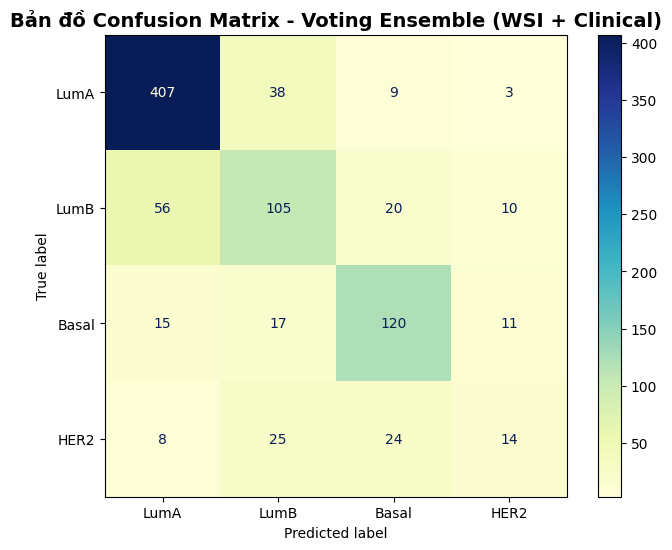

In [5]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

all_preds = []
all_targets = []

for train_idx, test_idx in skf.split(X_fusion, y_data):
    X_train, X_test = X_fusion[train_idx], X_fusion[test_idx]
    y_train, y_test = y_data[train_idx], y_data[test_idx]
    
    best_model.fit(X_train, y_train)
    preds = best_model.predict(X_test)
    
    all_preds.extend(preds)
    all_targets.extend(y_test)

cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LumA', 'LumB', 'Basal', 'HER2'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix - {best_model_name} (WSI + Clinical Early Fusion)', fontsize=14, fontweight='bold')
plt.show()